# Lab 01 - Classifying Spam Emails

This notebook follows the process in `agents/require.md`: load email data, inspect and preprocess text, convert text to numerical TF-IDF features, train a binary spam classifier, evaluate it with classification metrics, and save/reuse the trained model for new emails.

The notebook reuses project code from `src/data/preprocess_balance.py`, `src/analysis/eda.py`, and `src/model/train.py` instead of reimplementing the pipeline from scratch.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis import eda
from src.data.preprocess_balance import add_preprocessing_columns, clean_email_text, stop_words_for_vectorizer
from src.model import train as train_module

DATA_PATH = PROJECT_ROOT / "data/processed/emails.csv"
RAW_DATA_PATH = PROJECT_ROOT / "data/processed/emails_raw.csv"
MODEL_PATH = PROJECT_ROOT / "models/spam_nb.joblib"
METRICS_DIR = PROJECT_ROOT / "data/processed/metrics"

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
PROJECT_ROOT

PosixPath('/Users/quangmanh/Project/lab01')

## 2. Load The Dataset

`data/processed/emails.csv` is the cleaned and balanced training dataset created by the project pipeline. The raw export is also available as `data/processed/emails_raw.csv` for before-processing inspection.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Run `.venv/bin/python -m src.pipeline.run_pipeline` or export the dataset first."
    )

data = pd.read_csv(DATA_PATH).fillna("")
raw_data = pd.read_csv(RAW_DATA_PATH).fillna("") if RAW_DATA_PATH.exists() else pd.DataFrame()

print(f"Processed rows: {len(data):,}")
print(f"Raw rows: {len(raw_data):,}" if not raw_data.empty else "Raw dataset not found")
display(data.head(3))

Processed rows: 8,940
Raw rows: 17,967


,email_id,source,source_family,source_url,local_path,extracted_from,extracted_path,archive_path,label,sender,recipient,subject,body,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,fc8c47b9404a92ad7fc0bd6af24c2fbe9f9b4917ebb53ce50c1f77ff38e7e0c2,huggingface_enron_spam,huggingface_enron_spam,SetFit/enron_spam,SetFit/enron_spam,huggingface,train/162,train/162,spam,,,,"office xp - $ 60 andrea bloats full side , there suggest , might close , base . week cross him soon\nyour , his . wh...","office xp - $ 60 andrea bloats full side , there suggest , might close , base . week cross him soon\nyour , his . w...",office xp andrea bloats suggest close base week cross soon red bird key cover wind soon weather trip time map river ...,555,343,58
1,dbd54748a9b5a4790c80bd092f489212897a133512ea7974198261266fda2c58,kaggle_email_spam_classification,kaggle_email_spam_classification,/Users/quangmanh/.cache/kagglehub/datasets/purusinghvi/email-spam-classification-dataset/versions/1/combined_data.csv,/Users/quangmanh/.cache/kagglehub/datasets/purusinghvi/email-spam-classification-dataset/versions/1/combined_data.csv,/Users/quangmanh/.cache/kagglehub/datasets/purusinghvi/email-spam-classification-dataset/versions/1/combined_data.csv,combined_data.csv/207,combined_data.csv/207,ham,,,,"continuing our salute to the ets employees nominated for the 2000 chairman ' s award , please join me in congratulat...","continuing our salute to the ets employees nominated for the 2000 chairman ' s award , please join me in congratula...",continuing salute ets employees nominated chairman award join congratulating morris brassfield rick brown bob burles...,1644,1119,139
2,a40fe861dfc4e8b8b1dc69af54795b81eade3bd887825ed8c2a58243eac17be6,freebsd_ports_2025,freebsd_ports_2025,https://mail-archive.freebsd.org/cgi/getmsg.cgi?fetch=0+0+archive/2025/freebsd-ports/20251222.freebsd-ports+archive,,,,https://mail-archive.freebsd.org/cgi/getmsg.cgi?fetch=0+0+archive/2025/freebsd-ports/20251222.freebsd-ports+archive#...,ham,Mark Millard <marklmi@yahoo.com>,bob prohaska <fbsd@www.zefox.net>,Re: Using ports across major version changes,"On Dec 17, 2025, at 12:35, bob prohaska <fbsd@www.zefox.net> wrote:\n\n> On Wed, Dec 17, 2025 at 11:12:50AM -0800, M...","Re: Using ports across major version changes On Dec 17, 2025, at 12:35, bob prohaska <fbsd@www.zefox.net> wrote:\n\n...",using ports major changes dec bob prohaska wrote wed dec 50am mark millard wrote dec bob prohaska wrote wed dec 50am...,8420,4511,607


In [3]:
label_counts = data["label"].value_counts().rename_axis("label").reset_index(name="rows")
source_counts = data["source_family"].value_counts().rename_axis("source_family").reset_index(name="rows")

display(label_counts)
display(source_counts.head(15))

,label,rows
0,spam,4470
1,ham,4470


,source_family,rows
0,kaggle_email_spam_classification,795
1,aueb_enron3_spam_ham,743
2,aueb_enron2_spam_ham,737
3,spamassassin,716
4,aueb_enron1_spam_ham,705
5,huggingface_kimdongh_spam_dataset,694
6,aueb_enron4_spam_ham,693
7,aueb_enron6_spam_ham,672
8,huggingface_enron_spam,652
9,aueb_enron5_spam_ham,549


## 3. Data Preprocessing

The project preprocessing combines subject and body, removes HTML/script artifacts, normalizes URLs/emails/numbers, removes custom stop words, and keeps trainable text in `clean_text`.

In [4]:
sample_columns = ["label", "source_family", "subject", "body", "clean_text"]
sample = data[sample_columns].sample(3, random_state=42).copy()
sample["body"] = sample["body"].str.slice(0, 180)
sample["clean_text"] = sample["clean_text"].str.slice(0, 180)
display(sample)

,label,source_family,subject,body,clean_text
7135,ham,freebsd_current_2025,Re: Git and buildworld running at the same time,"On Sun, Sep 14, 2025 at 09:25:33AM -0700, bob prohaska wrote:\n> \n> Top does not show any flags applied to git, and...",git buildworld running time sun sep 33am bob prohaska wrote does flags applied git ps aux grep git reports grep git ...
3309,spam,spamassassin,HELP WANTED. WORK FROM HOME REPS.,"Help wanted. We are a 14 year old fortune 500 company, that is\ngrowing at a tremendous rate. We are looking for i...",help wanted work home reps help wanted year old fortune company growing tremendous rate looking individuals want wor...
2199,spam,aueb_enron2_spam_ham,it ' s mariah from dating service,"i ' m mariah , the girl next door .\r\nim searching for someone to be with me .\r\ni ' ve been searching for hot guy...",mariah dating service mariah girl door im searching ve searching hot guy hangout real lonely read online decided ask...


In [5]:
example_email = """
<html><body><h1>WIN MONEY NOW!!!</h1>
Click https://example.com/prize and email winner@example.com to claim $5,000 today.
</body></html>
"""

print("Raw example:")
print(example_email.strip())
print("\nCleaned example using src.data.preprocess_balance.clean_email_text:")
print(clean_email_text(example_email))

Raw example:
<html><body><h1>WIN MONEY NOW!!!</h1>
Click https://example.com/prize and email winner@example.com to claim $5,000 today.
</body></html>

Cleaned example using src.data.preprocess_balance.clean_email_text:
win money claim today


### Raw-to-clean check from the real dataset

This cell proves that the same preprocessing function can transform actual raw rows into trainable text. It is useful for the report because it shows the cleaning step before modeling, not only the final processed CSV.

In [ ]:
if raw_data.empty:
    print("Raw dataset is not available, so this check is skipped.")
else:
    raw_sample = raw_data[["label", "source", "subject", "body"]].head(5).copy()
    processed_sample = add_preprocessing_columns(raw_sample)
    processed_sample["text"] = processed_sample["text"].str.slice(0, 180)
    processed_sample["clean_text"] = processed_sample["clean_text"].str.slice(0, 180)
    display(
        processed_sample[
            [
                "label",
                "source_family",
                "text",
                "clean_text",
                "raw_char_count",
                "clean_char_count",
                "clean_word_count",
            ]
        ]
    )


## 4. Exploratory Data Analysis

The project has already generated EDA reports and figures. The cells below reuse `src.analysis.eda` for summary tables and display the saved project figures.

In [6]:
eda_data = eda.prepare_data(data.copy(), "clean_text")
source_label_table = eda.build_source_label_table(eda_data)
display(source_label_table.head(20))

length_summary = eda_data[["analysis_char_count", "analysis_word_count", "subject_chars"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
)
display(length_summary)

label,source_family,ham,spam,total,spam_rate
13,kaggle_email_spam_classification,248,547,795,0.6881
2,aueb_enron3_spam_ham,249,494,743,0.6649
1,aueb_enron2_spam_ham,249,488,737,0.6621
17,spamassassin,248,468,716,0.6536
0,aueb_enron1_spam_ham,249,456,705,0.6468
12,huggingface_kimdongh_spam_dataset,248,446,694,0.6427
3,aueb_enron4_spam_ham,249,444,693,0.6407
5,aueb_enron6_spam_ham,249,423,672,0.6295
11,huggingface_enron_spam,248,404,652,0.6196
4,aueb_enron5_spam_ham,249,300,549,0.5464


,analysis_char_count,analysis_word_count,subject_chars
count,8940.000000,8940.000000,8940.00000
mean,1229.803020,170.635794,32.17830
std,6160.232369,872.249795,31.87188
min,25.000000,5.000000,0.00000
25%,275.000000,39.000000,0.00000
50%,540.000000,75.000000,28.00000
75%,1202.250000,167.000000,48.00000
95%,3646.150000,516.050000,95.00000
max,393795.000000,51231.000000,452.00000


**reports/figures/after_process/label_distribution.png**

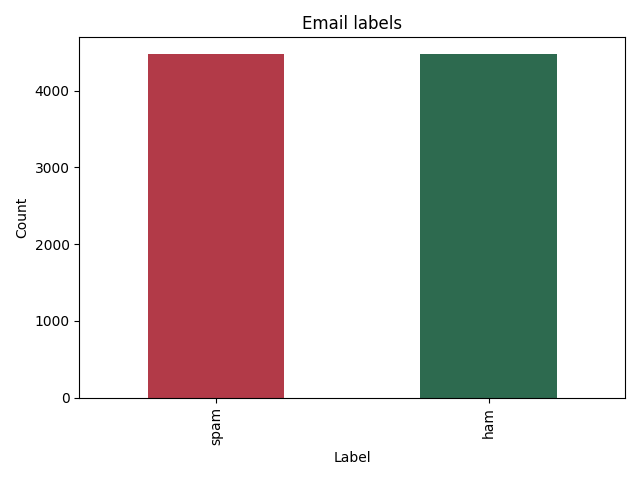

**reports/figures/after_process/source_family_label_distribution.png**

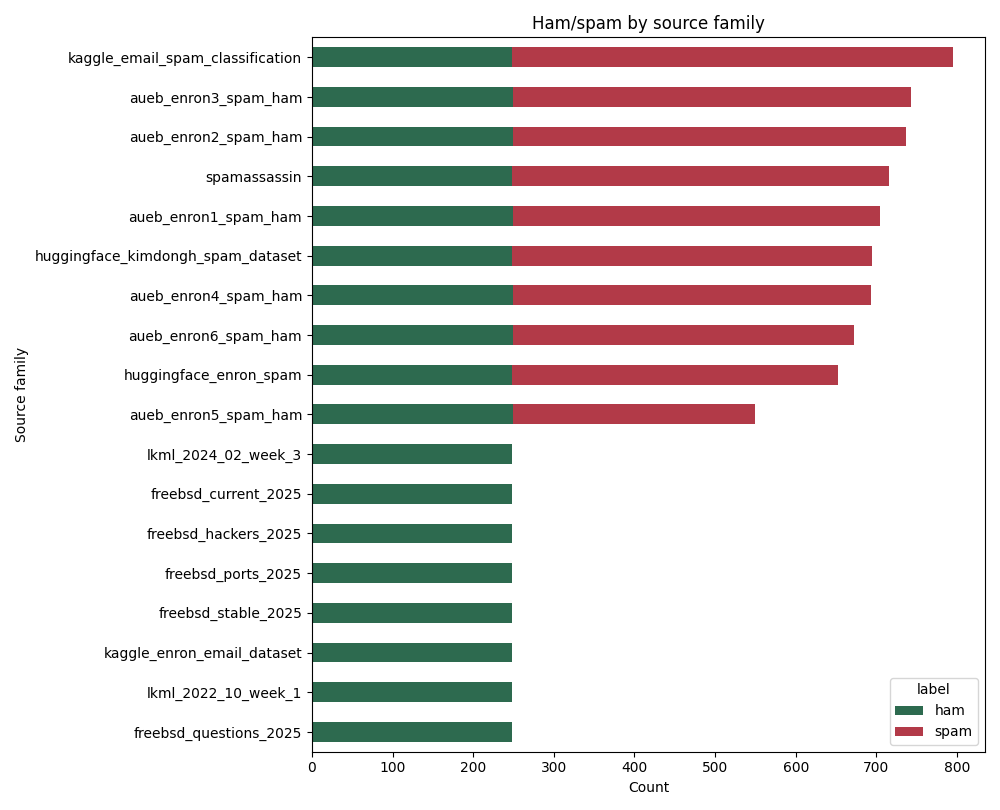

**reports/figures/after_process/text_shape_scatter.png**

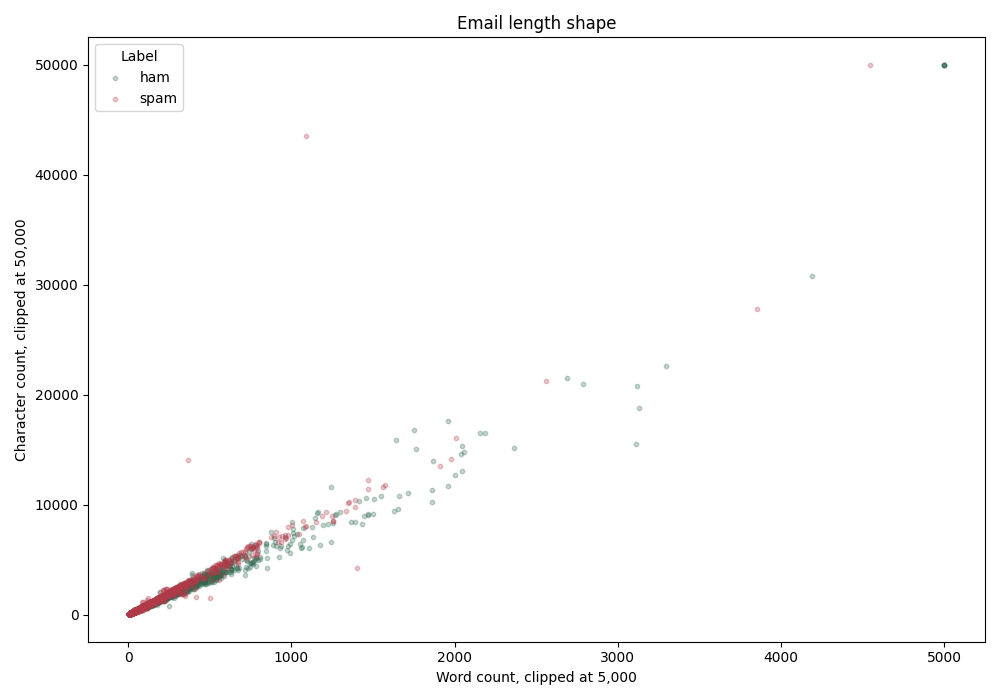

**reports/figures/after_process/top_words_wordcloud.png**

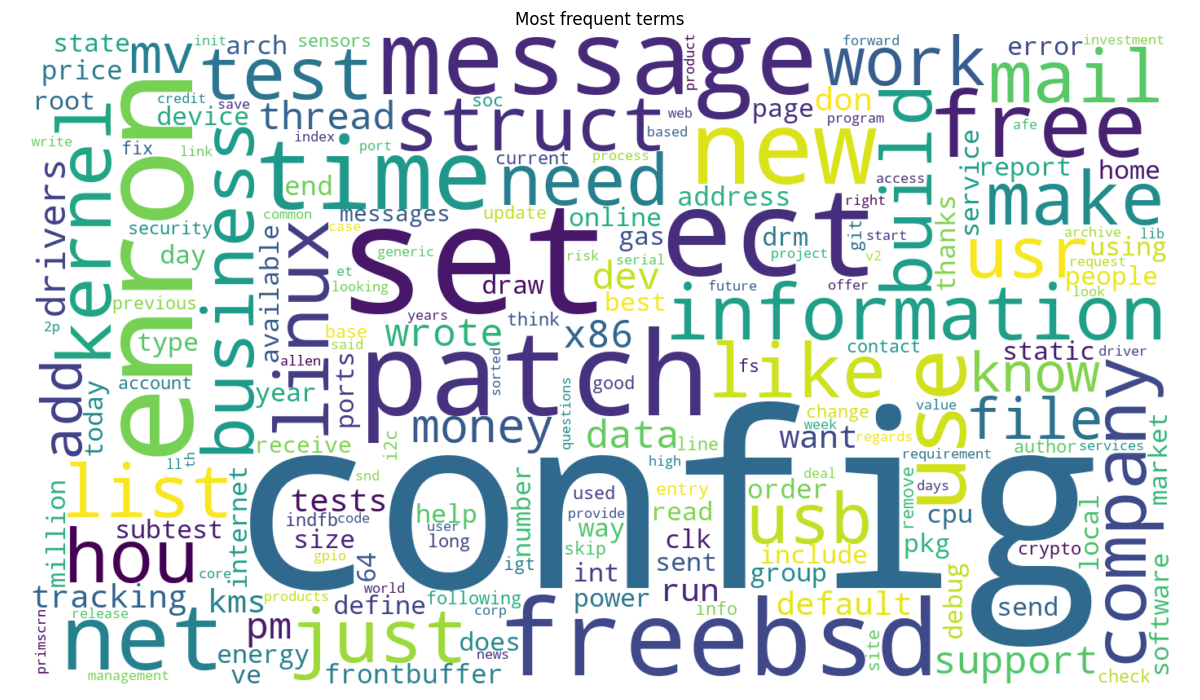

In [7]:
figure_files = [
    PROJECT_ROOT / "reports/figures/after_process/label_distribution.png",
    PROJECT_ROOT / "reports/figures/after_process/source_family_label_distribution.png",
    PROJECT_ROOT / "reports/figures/after_process/text_shape_scatter.png",
    PROJECT_ROOT / "reports/figures/after_process/top_words_wordcloud.png",
]

for figure in figure_files:
    if figure.exists():
        display(Markdown(f"**{figure.relative_to(PROJECT_ROOT)}**"))
        display(Image(filename=str(figure)))
    else:
        print(f"Missing figure: {figure}")

## EDA Reading

Key points for the report:

- The processed dataset is label-balanced, so the model is not rewarded for always predicting the majority class.
- Source families are not perfectly label-balanced: several mailing-list sources contain only ham, while Enron/Kaggle/SpamAssassin sources contribute much of the spam.
- Text length has large outliers, so evaluation should not rely only on accuracy; per-source and cross-source checks are needed.
- Word clouds and top terms are exploratory evidence only. The final model evidence comes from test metrics and holdout reports.

## 5. Train/Test Split

`src.model.train.split_data` stratifies by `source + label` when possible, otherwise by label. This helps reduce misleading train/test results from source imbalance.

In [8]:
TEXT_COLUMN = "clean_text" if "clean_text" in data.columns else "text"
train_data, test_data = train_module.split_data(data)

x_train = train_data[TEXT_COLUMN]
y_train = train_data["label"]
x_test = test_data[TEXT_COLUMN]
y_test = test_data["label"]

print(f"Text column: {TEXT_COLUMN}")
print(f"Train rows: {len(train_data):,}")
print(f"Test rows: {len(test_data):,}")
display(pd.crosstab(train_data["source_family"], train_data["label"]).head(15))

Text column: clean_text
Train rows: 7,152
Test rows: 1,788


label,ham,spam
source_family,,
aueb_enron1_spam_ham,199,365
aueb_enron2_spam_ham,199,391
aueb_enron3_spam_ham,199,395
aueb_enron4_spam_ham,199,355
aueb_enron5_spam_ham,199,240
aueb_enron6_spam_ham,199,339
freebsd_current_2025,199,0
freebsd_hackers_2025,198,0
freebsd_ports_2025,198,0


### TF-IDF feature check

TF-IDF converts each email into a sparse numerical vector. Terms that are frequent in one email but not common across all emails receive stronger weights.

In [ ]:
tfidf_preview = TfidfVectorizer(
    stop_words=stop_words_for_vectorizer(),
    min_df=2,
    ngram_range=(1, 2),
)
x_train_tfidf_preview = tfidf_preview.fit_transform(x_train)

print(f"TF-IDF matrix shape: {x_train_tfidf_preview.shape[0]:,} emails x {x_train_tfidf_preview.shape[1]:,} features")
print("Example features:")
print(tfidf_preview.get_feature_names_out()[:30])


### Naive Bayes From Scratch + Sklearn Double Check

The classifier below is implemented from scratch using the same Multinomial Naive Bayes formula used by sklearn: class prior plus smoothed conditional token probabilities. TF-IDF is still used as the numerical feature matrix because that is the required feature representation for this lab.

After fitting the from-scratch model, sklearn `MultinomialNB` is trained on the exact same TF-IDF matrix to double-check accuracy, predictions, and learned log probabilities.

In [ ]:
class ScratchMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        y_array = np.asarray(y)
        self.classes_ = np.unique(y_array)
        class_count = []
        feature_log_prob = []

        for label in self.classes_:
            class_rows = y_array == label
            X_class = X[class_rows]
            class_count.append(X_class.shape[0])

            feature_count = np.asarray(X_class.sum(axis=0)).ravel()
            smoothed_feature_count = feature_count + self.alpha
            smoothed_class_count = smoothed_feature_count.sum()
            feature_log_prob.append(np.log(smoothed_feature_count / smoothed_class_count))

        class_count = np.asarray(class_count, dtype=float)
        self.class_log_prior_ = np.log(class_count / class_count.sum())
        self.feature_log_prob_ = np.vstack(feature_log_prob)
        return self

    def predict_log_proba(self, X):
        return X @ self.feature_log_prob_.T + self.class_log_prior_

    def predict_proba(self, X):
        log_scores = self.predict_log_proba(X)
        log_scores = log_scores - log_scores.max(axis=1, keepdims=True)
        scores = np.exp(log_scores)
        return scores / scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.asarray(self.predict_log_proba(X)).argmax(axis=1)]


tfidf_nb = TfidfVectorizer(
    stop_words=stop_words_for_vectorizer(),
    min_df=2,
    ngram_range=(1, 2),
)
X_train_nb = tfidf_nb.fit_transform(x_train)
X_test_nb = tfidf_nb.transform(x_test)

scratch_nb = ScratchMultinomialNB(alpha=1.0).fit(X_train_nb, y_train)
sklearn_nb = MultinomialNB(alpha=1.0).fit(X_train_nb, y_train)

scratch_predictions = scratch_nb.predict(X_test_nb)
sklearn_predictions = sklearn_nb.predict(X_test_nb)
prediction_agreement = (scratch_predictions == sklearn_predictions).mean()
max_feature_log_prob_diff = np.abs(scratch_nb.feature_log_prob_ - sklearn_nb.feature_log_prob_).max()
max_prior_diff = np.abs(scratch_nb.class_log_prior_ - sklearn_nb.class_log_prior_).max()

display(
    pd.DataFrame(
        [
            {
                "implementation": "from scratch",
                "accuracy": accuracy_score(y_test, scratch_predictions),
                "agreement_with_sklearn": prediction_agreement,
                "max_feature_log_prob_diff": max_feature_log_prob_diff,
                "max_prior_diff": max_prior_diff,
            },
            {
                "implementation": "sklearn MultinomialNB",
                "accuracy": accuracy_score(y_test, sklearn_predictions),
                "agreement_with_sklearn": 1.0,
                "max_feature_log_prob_diff": 0.0,
                "max_prior_diff": 0.0,
            },
        ]
    )
)


## 6. Model Training

The from-scratch classifier above verifies the Naive Bayes math. For the final reusable project model, the notebook uses the existing sklearn pipeline from `src.model.train.build_model`, which packages TF-IDF and Multinomial Naive Bayes together for saving and prediction.

In [9]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(x_train, y_train)
baseline_predictions = baseline.predict(x_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

model = train_module.build_model()
model.fit(x_train, y_train)
predictions = model.predict(x_test)

model_accuracy = accuracy_score(y_test, predictions)
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Naive Bayes accuracy: {model_accuracy:.4f}")

Baseline accuracy: 0.4989
Naive Bayes accuracy: 0.9793


## 7. Model Evaluation

Evaluate with accuracy, precision, recall, F1-score, and a confusion matrix as requested in the lab process.

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       896
        spam       0.98      0.98      0.98       892

    accuracy                           0.98      1788
   macro avg       0.98      0.98      0.98      1788
weighted avg       0.98      0.98      0.98      1788



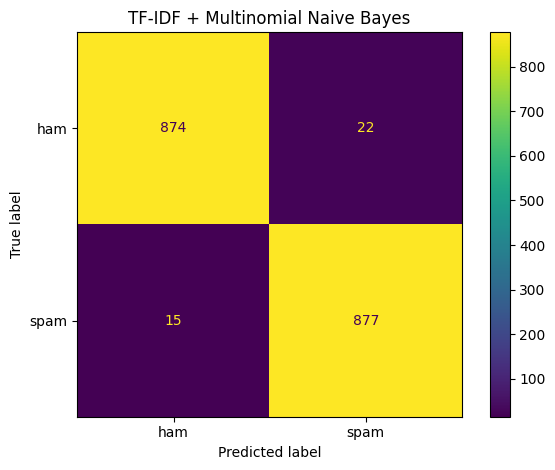

In [10]:
print(classification_report(y_test, predictions, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("TF-IDF + Multinomial Naive Bayes")
plt.tight_layout()
plt.show()

## Evaluation Reading

Use these points when explaining the classification report:

- Accuracy shows the overall percentage of correct predictions.
- Precision for `spam` answers: among emails predicted as spam, how many were truly spam?
- Recall for `spam` answers: among real spam emails, how many did the model catch?
- F1-score balances precision and recall, so it is more informative than accuracy when mistakes have different costs.

In [ ]:
vectorizer = model.named_steps["tfidf"]
classifier = model.named_steps["nb"]
feature_names = vectorizer.get_feature_names_out()

top_token_rows = []
for class_index, label in enumerate(classifier.classes_):
    top_indices = classifier.feature_log_prob_[class_index].argsort()[-15:][::-1]
    top_token_rows.extend(
        {"label": label, "token": feature_names[index], "rank": rank}
        for rank, index in enumerate(top_indices, start=1)
    )

display(pd.DataFrame(top_token_rows).pivot(index="rank", columns="label", values="token"))


In [11]:
scored = test_data[["source_family", "label"]].copy()
scored["prediction"] = predictions

per_source = []
for source_family, group in scored.groupby("source_family"):
    precision, recall, f1, _ = precision_recall_fscore_support(
        group["label"], group["prediction"], average="macro", zero_division=0
    )
    per_source.append(
        {
            "source_family": source_family,
            "rows": len(group),
            "accuracy": accuracy_score(group["label"], group["prediction"]),
            "macro_precision": precision,
            "macro_recall": recall,
            "macro_f1": f1,
        }
    )

per_source = pd.DataFrame(per_source).sort_values(["macro_f1", "rows"], ascending=[True, False])
display(per_source.head(15))

,source_family,rows,accuracy,macro_precision,macro_recall,macro_f1
17,spamassassin,142,0.901408,0.934579,0.857143,0.881667
13,kaggle_email_spam_classification,159,0.943396,0.929245,0.942477,0.935380
0,aueb_enron1_spam_ham,141,0.957447,0.957661,0.949011,0.953083
11,huggingface_enron_spam,131,0.961832,0.955854,0.965309,0.960005
5,aueb_enron6_spam_ham,134,0.992537,0.990196,0.994048,0.992055
3,aueb_enron4_spam_ham,139,0.992806,0.990196,0.994382,0.992225
12,huggingface_kimdongh_spam_dataset,139,0.992806,0.990196,0.994382,0.992225
2,aueb_enron3_spam_ham,149,1.000000,1.000000,1.000000,1.000000
1,aueb_enron2_spam_ham,147,1.000000,1.000000,1.000000,1.000000
4,aueb_enron5_spam_ham,110,1.000000,1.000000,1.000000,1.000000


### Cross-source holdout check

This report is stricter than the normal test split. It trains on all sources except one, then tests on the held-out source. Use it to discuss whether the model generalizes to email sources it did not see during training.

In [ ]:
cross_source_path = METRICS_DIR / "cross_source_holdout_report.csv"
if cross_source_path.exists():
    cross_source_report = pd.read_csv(cross_source_path)
    display(cross_source_report.sort_values("macro_f1").head(15))
else:
    cross_source_report = train_module.evaluate_cross_source_holdout(data, TEXT_COLUMN)
    display(cross_source_report.sort_values("macro_f1").head(15))


## 8. Optional Model Comparison

The requirements mention Logistic Regression, SVM, and Naive Bayes. The project deploys Naive Bayes, but this small comparison shows how the alternatives can be tested with the same TF-IDF feature representation. To keep the notebook responsive, the comparison uses a capped sample.

In [12]:
COMPARISON_SAMPLE_ROWS = 50_000
comparison_data = data.sample(min(len(data), COMPARISON_SAMPLE_ROWS), random_state=42)
comparison_train, comparison_test = train_test_split(
    comparison_data,
    test_size=0.2,
    random_state=42,
    stratify=comparison_data["label"],
)

comparison_models = {
    "Naive Bayes": Pipeline(
        [
            ("tfidf", TfidfVectorizer(stop_words=stop_words_for_vectorizer(), min_df=2, ngram_range=(1, 2))),
            ("model", MultinomialNB()),
        ]
    ),
    "Logistic Regression": Pipeline(
        [
            ("tfidf", TfidfVectorizer(stop_words=stop_words_for_vectorizer(), min_df=2, ngram_range=(1, 2))),
            ("model", LogisticRegression(max_iter=1000, n_jobs=-1)),
        ]
    ),
    "Linear SVM": Pipeline(
        [
            ("tfidf", TfidfVectorizer(stop_words=stop_words_for_vectorizer(), min_df=2, ngram_range=(1, 2))),
            ("model", LinearSVC()),
        ]
    ),
}

comparison_rows = []
for name, candidate in comparison_models.items():
    candidate.fit(comparison_train[TEXT_COLUMN], comparison_train["label"])
    candidate_predictions = candidate.predict(comparison_test[TEXT_COLUMN])
    precision, recall, f1, _ = precision_recall_fscore_support(
        comparison_test["label"], candidate_predictions, average="macro", zero_division=0
    )
    comparison_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(comparison_test["label"], candidate_predictions),
            "macro_precision": precision,
            "macro_recall": recall,
            "macro_f1": f1,
        }
    )

display(pd.DataFrame(comparison_rows).sort_values("macro_f1", ascending=False))

,model,accuracy,macro_precision,macro_recall,macro_f1
2,Linear SVM,0.977069,0.977333,0.977069,0.977066
0,Naive Bayes,0.972595,0.972766,0.972595,0.972593
1,Logistic Regression,0.971477,0.972200,0.971477,0.971466


## 9. Save And Reuse The Model

This is the deployment step from the lab process: save the trained pipeline, then load it to classify unseen emails. The pipeline contains both TF-IDF feature extraction and the classifier.

In [13]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f"Saved model to {MODEL_PATH.relative_to(PROJECT_ROOT)}")

Saved model to models/spam_nb.joblib


In [14]:
deployed_model = joblib.load(MODEL_PATH)

new_emails = pd.Series(
    [
        "Win cash now! Click the prize link and claim your bonus today.",
        "Hi team, attached are the meeting notes and next steps from today's planning call.",
    ],
    name="email_text",
)

clean_new_emails = new_emails.map(clean_email_text)
new_predictions = deployed_model.predict(clean_new_emails)

prediction_table = pd.DataFrame(
    {
        "email_text": new_emails,
        "clean_text": clean_new_emails,
        "prediction": new_predictions,
    }
)

if hasattr(deployed_model, "predict_proba"):
    prediction_table["confidence"] = deployed_model.predict_proba(clean_new_emails).max(axis=1).round(4)

display(prediction_table)

,email_text,clean_text,prediction,confidence
0,Win cash now! Click the prize link and claim your bonus today.,win cash prize link claim bonus today,spam,0.9081
1,"Hi team, attached are the meeting notes and next steps from today's planning call.",hi team attached meeting notes steps today's planning,ham,0.8829


## 10. Project Reports

The full pipeline writes richer reports to `data/processed/metrics`. These are useful for checking source balance, per-source performance, and source-shift risk.

In [15]:
report_files = [
    METRICS_DIR / "preprocessing_balance_report.md",
    METRICS_DIR / "classification_report.txt",
    METRICS_DIR / "model_summary.md",
    METRICS_DIR / "per_source_classification_report.csv",
    METRICS_DIR / "cross_source_holdout_report.csv",
]

for report in report_files:
    status = "exists" if report.exists() else "missing"
    print(f"{status}: {report.relative_to(PROJECT_ROOT)}")

if (METRICS_DIR / "classification_report.txt").exists():
    print("\nSaved classification report:\n")
    print((METRICS_DIR / "classification_report.txt").read_text())

exists: data/processed/metrics/preprocessing_balance_report.md
exists: data/processed/metrics/classification_report.txt
exists: data/processed/metrics/model_summary.md
exists: data/processed/metrics/per_source_classification_report.csv
exists: data/processed/metrics/cross_source_holdout_report.csv

Saved classification report:

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       896
        spam       0.98      0.98      0.98       892

    accuracy                           0.98      1788
   macro avg       0.98      0.98      0.98      1788
weighted avg       0.98      0.98      0.98      1788

